# Deteksi dini terhadap penderita penyakit jantung

## 1. Perumusan Masalah

Penyakit jantung merupakan salah satu penyebab kematian utama di seluruh dunia. Menurut World Health Organization (WHO), penyakit jantung iskemik adalah penyebab kematian nomor satu secara global, bertanggung jawab atas 8,6 juta kematian pada tahun 2021.

Sebagai seorang data  scientist, Anda diminta turut terlibat dalam upaya pemerintah untuk menurunkan angka kematian karena penyakit jantung dengan mengembangkan upaya deteksi dini sehingga penderita penyait jantung dapat ditangani sedini mungkin. Dengan melakukan deteksi dini diharapkan pengobatan penyakit jantung dapat meningkatkan peluang kesembuhan pasien.

### Permasalahan Bisnis

Bisakah penyakit jantung dilakukan deteksi dini sehingga penderita penyakit jantung dapat ditangani sedini mungkin

### Permasalahan Teknis

Memprediksi variabel target yaitu `HeartDisease` pada dataset `heart.csv` diantara 1 (Terkena penyakit jantung) dan 0 (tidak terkena penyakit jantung) dari sebelas fitur lainnya

## 2. Pengumpulan Data

Data diambil dari repository github https://github.com/arubhasy/dataset/blob/main/heart.csv pada dataset `heart.csv` yang merupakan dataset serangan jantung.

Dataset tersebut diunduh dan akan digunakan dalam proses deteksi dini terhadap penderita penyakit jantung pada pipeline ini.

In [45]:
# mengimpor library python
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# membaca data dari direktori komputer
dataset = pd.read_csv('heart.csv')

display(dataset)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,NaN,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49.0,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37.0,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48.0,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54.0,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68.0,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57.0,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57.0,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## 3. Penelaahan Data

### A. Mengidentifikasi Tipe Data Setiap Fitur

Tahapan pertama yang dilakukan adalah mengidentifikasi tipe data setiap fitur yang ada pada dataset `heart.csv`, tahapan ini diperlukan untuk memahami setiap entri data yang akan diproses ditahapan selanjutnya

In [46]:
# mengidentifikasi variabel yang awalnya kategorikal
# (Sebelum konversi, variabel kategorikan memiliki tipe data object)

original_categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

print("Nilai unik untuk setiap variabel kategorikal (Setelah konversi) :")
for col in original_categorical_cols:
    if col in dataset.columns:
        print(f"\nVariabel: {col}")
        print(dataset[col].unique())
    else:
        print(f"\nVariabel: {col} tidak ditemukan dalam dataset.")

Nilai unik untuk setiap variabel kategorikal (Setelah konversi) :

Variabel: Sex
['M' 'F' nan]

Variabel: ChestPainType
['ATA' 'NAP' 'ASY' 'TA']

Variabel: RestingECG
['Normal' 'ST' 'LVH']

Variabel: ExerciseAngina
['N' 'Y']

Variabel: ST_Slope
['Up' 'Flat' 'Down']


In [47]:
print(dataset.dtypes)

Age               float64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


Berdasarkan jenis data setiap variabel:

*   **Age (float64):** Variabel ini memiliki tipe data float64, yang menunjukkan bahwa usia direpresentasikan sebagai angka desimal. Namun, perlu diperhatikan bahwa ada nilai yang hilang (NaN) seperti yang terlihat dari output `dataset.describe()`, yang perlu ditangani sebelum analisis lebih lanjut.
*   **Sex (object):** Variabel ini memiliki tipe data object, yang menunjukkan bahwa jenis kelamin direpresentasikan sebagai string (teks). Ini adalah variabel kategorikal.
*   **ChestPainType (object):** Variabel ini juga memiliki tipe data object, menunjukkan jenis nyeri dada direpresentasikan sebagai string. Ini adalah variabel kategorikal.
*   **RestingBP (int64):** Variabel ini memiliki tipe data int64, menunjukkan tekanan darah saat istirahat direpresentasikan sebagai bilangan bulat. Ini adalah variabel numerikal.
*   **Cholesterol (int64):** Variabel ini memiliki tipe data int64, menunjukkan kadar kolesterol direpresentasikan sebagai bilangan bulat. Ini adalah variabel numerikal.
*   **FastingBS (int64):** Variabel ini memiliki tipe data int64, menunjukkan gula darah puasa direpresentasikan sebagai bilangan bulat. Ini adalah variabel biner (0 atau 1).
*   **RestingECG (object):** Variabel ini memiliki tipe data object, menunjukkan hasil elektrokardiogram saat istirahat direpresentasikan sebagai string. Ini adalah variabel kategorikal.
*   **MaxHR (int64):** Variabel ini memiliki tipe data int64, menunjukkan detak jantung maksimum direpresentasikan sebagai bilangan bulat. Ini adalah variabel numerikal.
*   **ExerciseAngina (object):** Variabel ini memiliki tipe data object, menunjukkan adanya angina saat berolahraga direpresentasikan sebagai string. Ini adalah variabel biner (Yes atau No).
*   **Oldpeak (float64):** Variabel ini memiliki tipe data float64, menunjukkan depresi ST saat istirahat relatif terhadap latihan direpresentasikan sebagai angka desimal. Ini adalah variabel numerikal.
*   **ST_Slope (object):** Variabel ini memiliki tipe data object, menunjukkan kemiringan segmen ST selama latihan puncak direpresentasikan sebagai string. Ini adalah variabel kategorikal.
*   **HeartDisease (int64):** Variabel ini memiliki tipe data int64, menunjukkan keberadaan penyakit jantung direpresentasikan sebagai bilangan bulat. Ini adalah variabel target biner (0 atau 1).

### B. Menampilkan statistik deskriptif dari data input

Pada tahapan ini dilakukan untuk mendeskripsikan dan dataset dan memahami lebih dalam sifat data

In [48]:
display(dataset.describe())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,911.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,54.102086,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,12.988393,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,0.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,177.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Berdasarkan statistik deskriptif dari data input (`dataset.describe()`):

**Variabel Numerikal:**

*   **Age:** Usia rata-rata dalam dataset adalah sekitar 54.1 tahun, dengan standar deviasi sekitar 13 tahun. Rentang usia cukup luas, dari minimum 0 (kemungkinan data yang salah atau outlier) hingga maksimum 177 (kemungkinan data yang salah atau outlier). Nilai kuartil pertama (25%) adalah 47 tahun, median (50%) adalah 54 tahun, dan kuartil ketiga (75%) adalah 60 tahun. Terdapat 911 data usia yang valid, menunjukkan ada beberapa nilai yang hilang.
*   **RestingBP (Tekanan Darah Saat Istirahat):** Tekanan darah rata-rata saat istirahat adalah sekitar 132.4 mmHg, dengan standar deviasi sekitar 18.5 mmHg. Rentangnya dari 0 (kemungkinan data yang salah atau outlier) hingga 200 mmHg. Sebagian besar data berada di kisaran normal, tetapi ada beberapa nilai yang tinggi.
*   **Cholesterol:** Kadar kolesterol rata-rata adalah sekitar 198.8 mg/dL, dengan standar deviasi sekitar 109.4 mg/dL. Rentangnya sangat luas, dari 0 hingga 603 mg/dL. Nilai 0 untuk kolesterol kemungkinan merupakan data yang hilang atau tidak valid.
*   **MaxHR (Detak Jantung Maksimum):** Detak jantung maksimum rata-rata adalah sekitar 136.8 bpm, dengan standar deviasi sekitar 25.5 bpm. Rentangnya dari 60 hingga 202 bpm.
*   **Oldpeak:** Rata-rata Oldpeak adalah sekitar 0.89, dengan standar deviasi sekitar 1.07. Rentangnya dari -2.6 hingga 6.2.

**Variabel Biner (FastingBS, HeartDisease):**

*   **FastingBS (Gula Darah Puasa > 120 mg/dL):** Rata-rata 0.233 menunjukkan bahwa sekitar 23.3% individu dalam dataset memiliki gula darah puasa lebih dari 120 mg/dL (nilai 1).
*   **HeartDisease:** Rata-rata 0.554 menunjukkan bahwa sekitar 55.4% individu dalam dataset memiliki penyakit jantung (nilai 1).

**Kesimpulan dari Statistik Deskriptif:**

*   Dataset ini berisi informasi tentang individu dengan berbagai karakteristik terkait kesehatan jantung.
*   Terdapat beberapa nilai yang hilang atau outlier dalam variabel 'Age', 'RestingBP', dan 'Cholesterol' yang perlu ditangani.
*   Distribusi variabel numerikal bervariasi, dengan beberapa variabel menunjukkan rentang yang luas dan potensi outlier.
*   Proporsi individu dengan gula darah puasa tinggi dan penyakit jantung cukup signifikan dalam dataset ini.

Analisis statistik deskriptif ini memberikan gambaran awal tentang sebaran data dan potensi masalah kualitas data yang perlu ditangani sebelum analisis lebih mendalam.

### C. Membuat Visualisasi Data

##### Menampilkan visualisasi variabel kategorikal (Sex, ChestPainType, RestingECG, ExerciseAngina, dan ST_SLope)

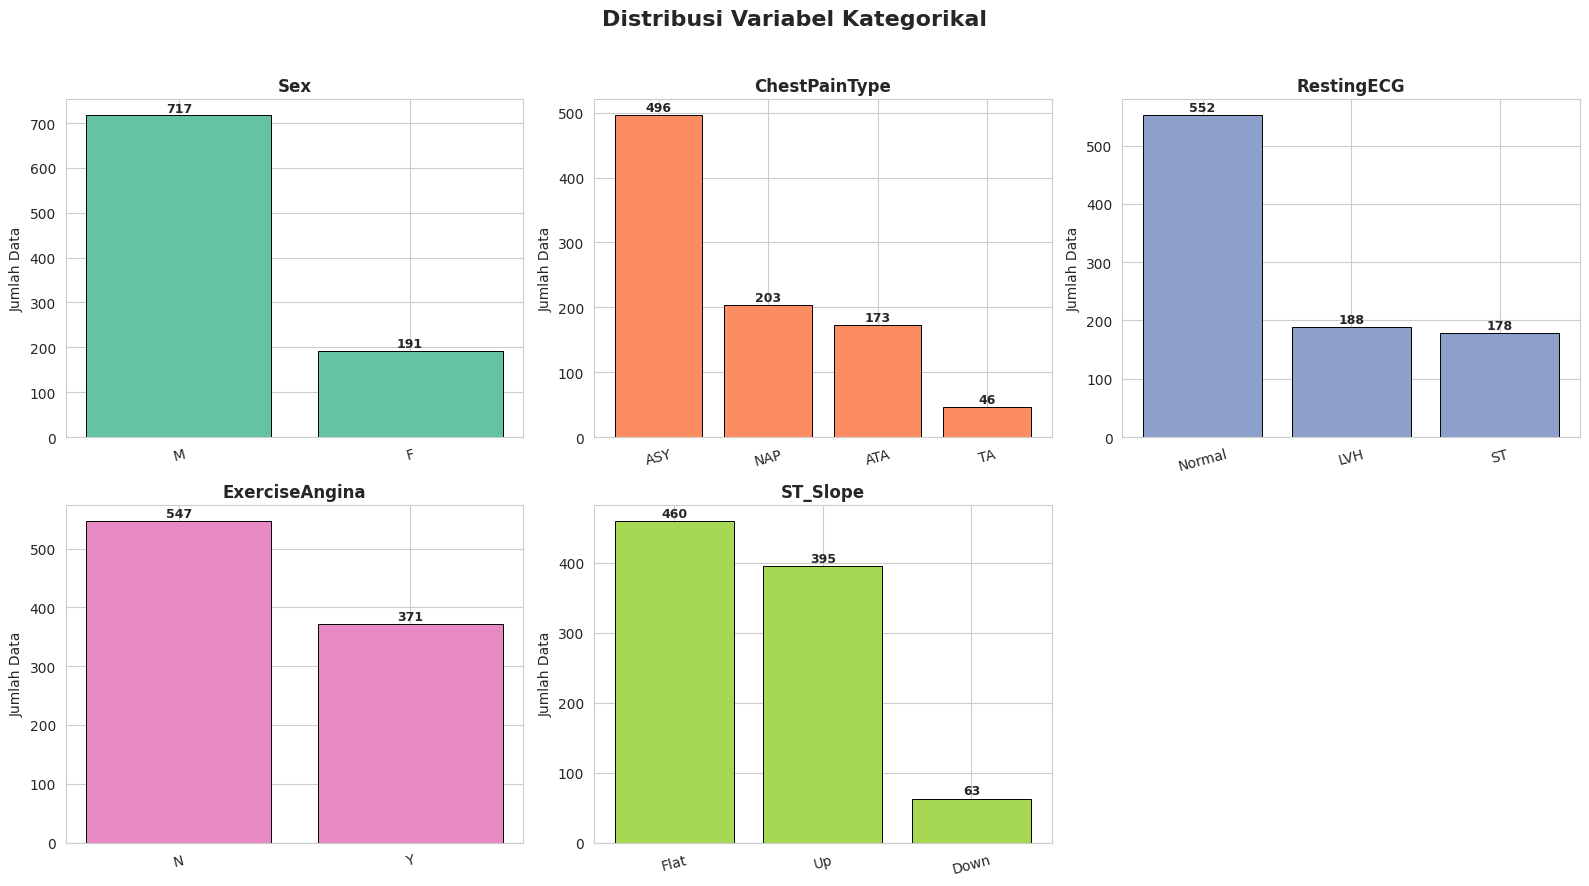

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = sns.color_palette('Set2')

for i, col in enumerate(categorical_cols):
    counts = dataset[col].value_counts()
    ax = axes[i]
    bars = ax.bar(counts.index, counts.values, color=colors[i], edgecolor='black', linewidth=0.7)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 2, str(int(height)),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Data')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

# hapus axis kosong kalau jumlah kolom ganjil
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribusi Variabel Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Jenis Kelamin (Sex)**

Dataset ini didominasi laki-laki (717 data) dibanding perempuan (191 data) — rasio hampir 4:1. Ketimpangan ini penting dicatat karena model yang dilatih dari data ini berpotensi lebih akurat memprediksi risiko jantung pada laki-laki, dan perlu divalidasi lebih hati-hati untuk kasus perempuan.

**Jenis Nyeri Dada (ChestPainType)**

Mayoritas pasien (496 data) mengalami ASY (Asymptomatic) — artinya tidak menunjukkan gejala nyeri dada khas sama sekali. Ini pola yang cukup mengkhawatirkan secara klinis: penyakit jantung sering "diam-diam" tanpa gejala jelas, sehingga variabel lain (seperti ST_Slope atau ExerciseAngina) menjadi krusial untuk deteksi dini.

**Hasil EKG Istirahat (RestingECG)**

Sebagian besar hasil EKG Normal (552 data), sedangkan LVH (pembesaran ventrikel kiri) dan ST-T abnormality masing-masing hanya sekitar 180 data. Artinya banyak pasien dengan EKG normal tetap berisiko terkena penyakit jantung — menegaskan bahwa EKG saja tidak cukup sebagai indikator tunggal.

**Angina Akibat Olahraga (ExerciseAngina)**

547 pasien tidak mengalami angina saat olahraga, sementara 371 mengalami. Proporsi yang cukup besar (~40%) mengalami nyeri dada saat beraktivitas fisik menunjukkan variabel ini punya sinyal yang cukup kuat untuk membedakan kondisi jantung yang bermasalah.

**Kemiringan Segmen ST (ST_Slope)**

Pola Flat (460) dan Up (395) mendominasi, sedangkan Down hanya 63 data — kelas minoritas yang cukup timpang. Secara klinis, ST_Slope dikenal sebagai salah satu prediktor kuat penyakit jantung, sehingga distribusi yang tidak seimbang ini perlu diperhatikan saat modeling (misalnya potensi bias terhadap kelas Down).

##### Menampilkan visualisasi Non-Kategorikal (Age, RestingBP, Cholesterol, FastingBS, dan OldPeak)

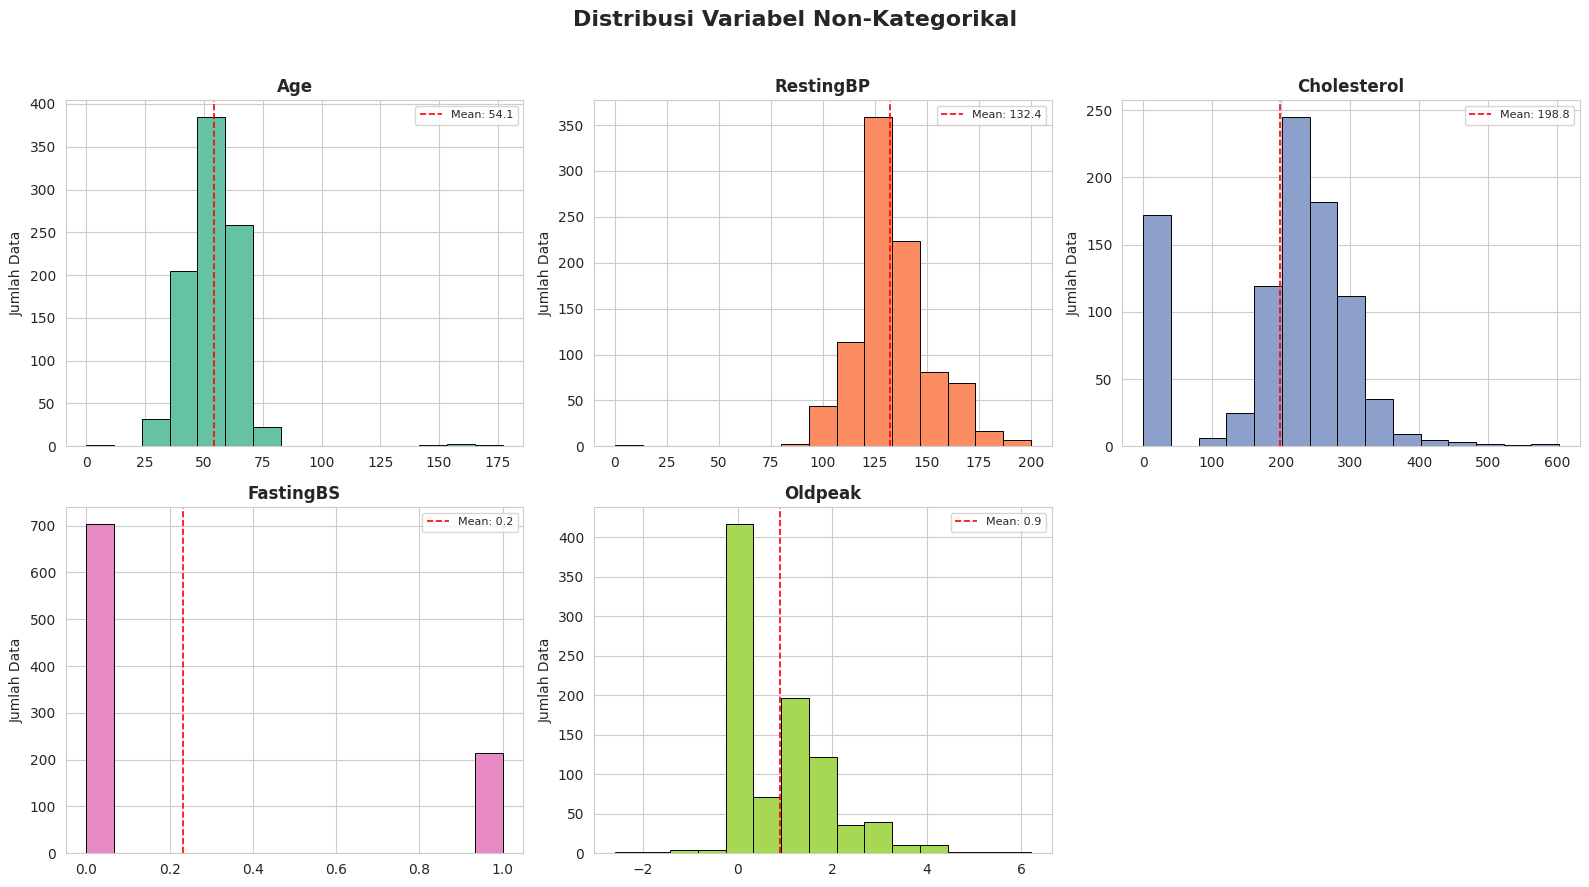

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'Oldpeak']

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = sns.color_palette('Set2')

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    ax.hist(dataset[col], bins=15, color=colors[i], edgecolor='black', linewidth=0.7)

    mean_val = dataset[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Data')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribusi Variabel Non-Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Membuat diagram Pie Chart dari variabel Kategorikal (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope)

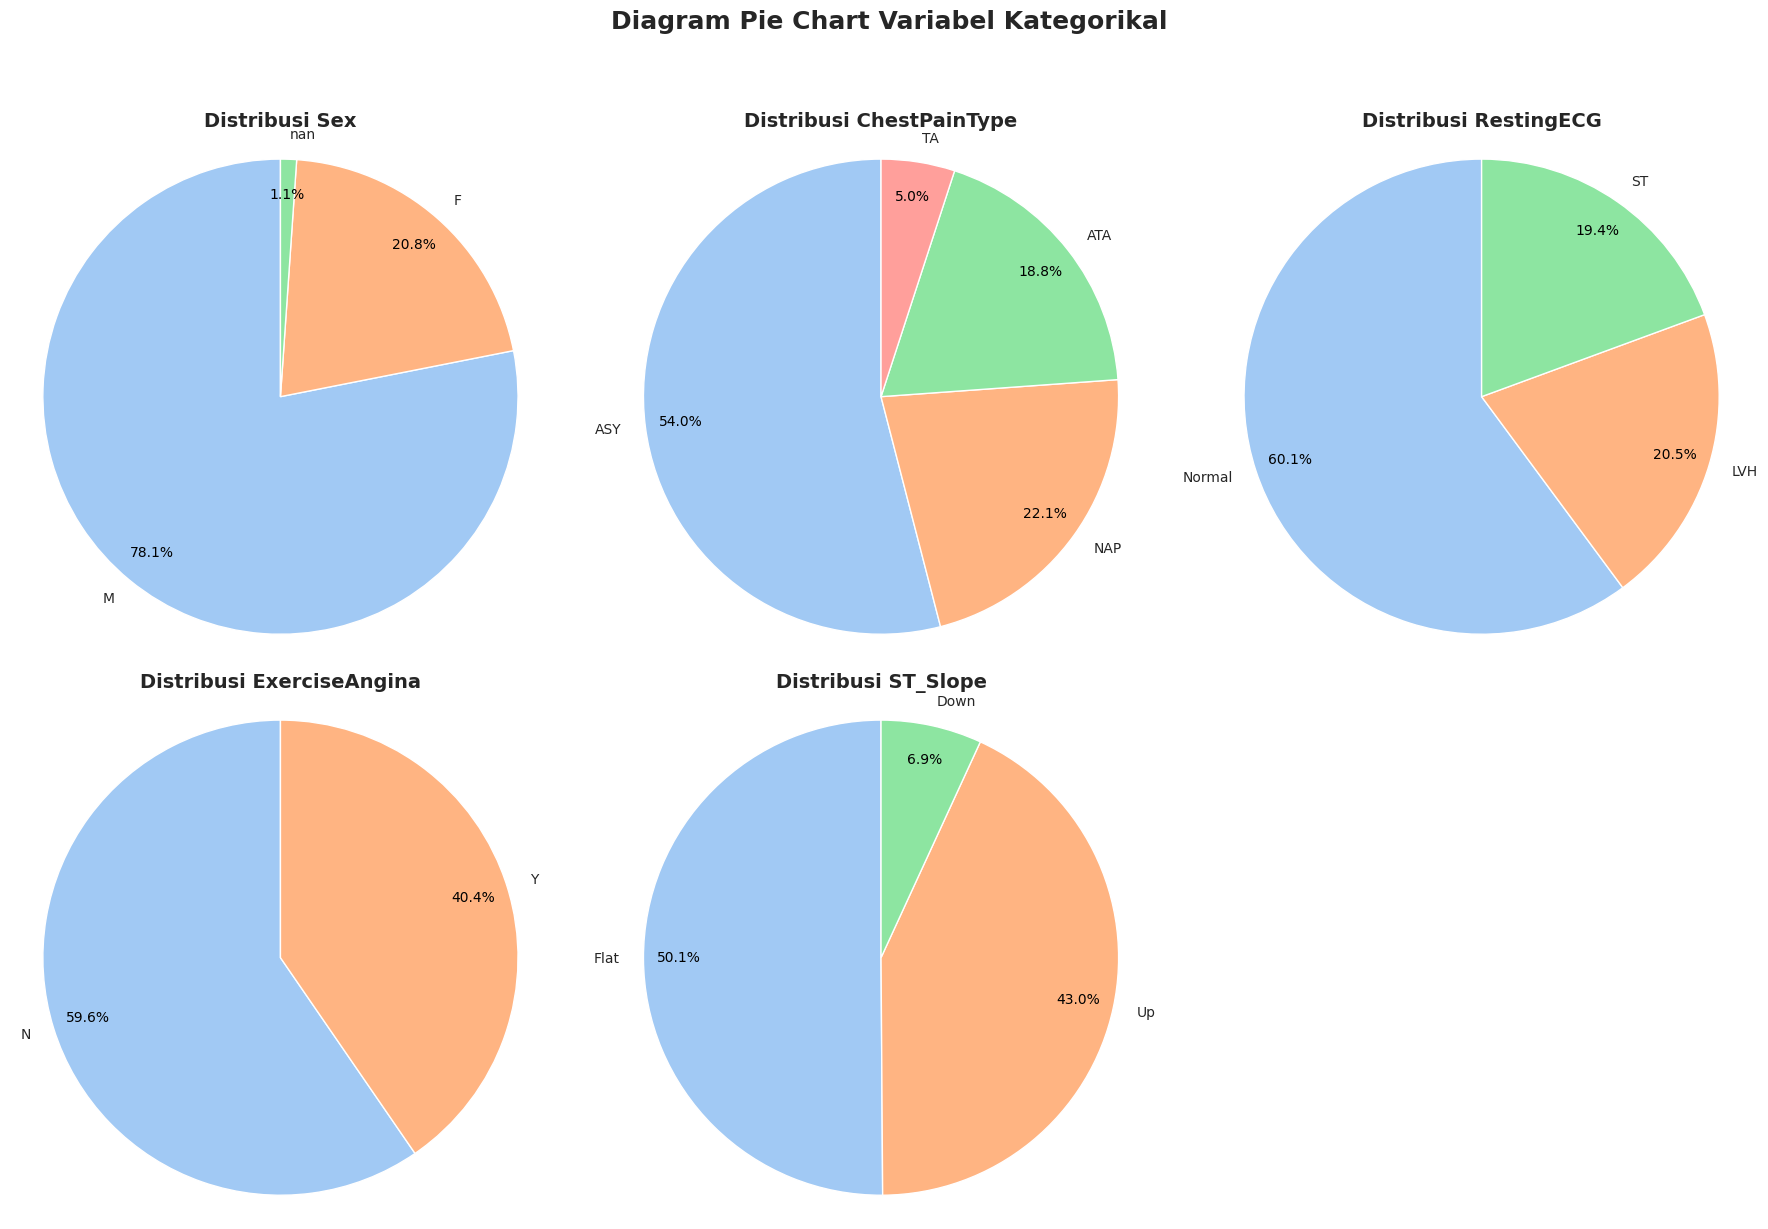

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols_for_pie = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_for_pie):
    ax = axes[i]
    counts = dataset[col].value_counts(dropna=False) # Include NaN if any for a complete picture
    labels = counts.index.tolist()
    sizes = counts.values.tolist()

    # Handle NaN label if it exists
    if pd.isna(labels[0]):
        labels[0] = 'NaN'

    # Plotting the pie chart
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
                                      colors=sns.color_palette('pastel', len(labels)),
                                      pctdistance=0.85, textprops={'fontsize': 10})

    # Ensure percentages are readable by making them white if background is dark
    for autotext in autotexts:
        autotext.set_color('black')

    ax.set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Remove any unused subplots
for j in range(len(categorical_cols_for_pie), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Diagram Pie Chart Variabel Kategorikal', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#### Korelasi antar variabel numerik

In [10]:
# Get numerical columns
numerical_cols = dataset.select_dtypes(include=np.number).columns

# Hitung matriks korelasi untuk variabel numerik
correlation_matrix = dataset[numerical_cols].corr(method='pearson')

# Tampilkan matriks korelasi
display(correlation_matrix)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.210568,-0.062391,0.127287,-0.300843,0.196534,0.212565
RestingBP,0.210568,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.062391,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.127287,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.300843,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.196534,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.212565,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


**Kesimpulan Korelasi Berdasarkan Koefisien Korelasi Pearson:**

Koefisien Korelasi Pearson mengukur kekuatan dan arah hubungan linier antara dua variabel numerik. Nilainya berkisar antara -1 hingga +1, di mana:
*   +1 menunjukkan korelasi positif sempurna
*   -1 menunjukkan korelasi negatif sempurna
*   0 menunjukkan tidak ada korelasi linier

Berdasarkan matriks korelasi:

*   **Korelasi dengan HeartDisease (Variabel Target):**
    *   `Oldpeak` memiliki korelasi positif moderat dengan `HeartDisease` (sekitar 0.40). Ini menunjukkan bahwa nilai Oldpeak yang lebih tinggi cenderung terkait dengan kemungkinan penyakit jantung yang lebih tinggi.
    *   `MaxHR` memiliki korelasi negatif moderat dengan `HeartDisease` (sekitar -0.40). Ini menunjukkan bahwa detak jantung maksimum yang lebih tinggi cenderung terkait dengan kemungkinan penyakit jantung yang lebih rendah.
    *   `FastingBS` memiliki korelasi positif lemah dengan `HeartDisease` (sekitar 0.27).
    *   `Age` memiliki korelasi positif lemah dengan `HeartDisease` (sekitar 0.21).
    *   `Cholesterol` memiliki korelasi negatif lemah dengan `HeartDisease` (sekitar -0.23).
    *   `RestingBP` memiliki korelasi positif sangat lemah dengan `HeartDisease` (sekitar 0.11).

*   **Korelasi Antar Variabel Prediktor Numerik:**
    *   Terdapat beberapa korelasi lemah hingga moderat antar variabel prediktor numerik (misalnya, Age dengan RestingBP sekitar 0.21, MaxHR dengan Cholesterol sekitar 0.24). Korelasi ini umumnya tidak terlalu tinggi, menunjukkan bahwa sebagian besar variabel prediktor numerik memberikan informasi yang relatif independen satu sama lain.

**Ringkasan:**

Analisis korelasi Pearson menunjukkan bahwa `Oldpeak` dan `MaxHR` memiliki korelasi yang paling kuat (meskipun moderat) dengan variabel target `HeartDisease`. Variabel numerik lainnya menunjukkan korelasi yang lebih lemah dengan `HeartDisease`. Korelasi antar variabel prediktor numerik umumnya rendah, yang merupakan hal baik karena menunjukkan sedikit multikolinearitas di antara fitur-fitur numerik. Informasi ini penting untuk pemilihan fitur dan pengembangan model prediksi penyakit jantung.

#### **Korelasi antara variabel Kategorikal dengan variabel Numerik**

In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Get categorical and numerical columns
categorical_cols = dataset.select_dtypes(include='object').columns
numerical_cols = dataset.select_dtypes(include=np.number).columns

# Perform ANOVA for each combination of categorical and numerical variables
anova_results = {}
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        # Handle potential missing values in numerical column
        temp_df = dataset[[cat_col, num_col]].dropna()
        if len(temp_df) > 0:
            try:
                # Fit the ANOVA model
                model = ols(f'{num_col} ~ C({cat_col})', data=temp_df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                anova_results[f'{cat_col} vs {num_col}'] = anova_table['PR(>F)'][0]
            except Exception as e:
                anova_results[f'{cat_col} vs {num_col}'] = f'Error: {e}'
        else:
            anova_results[f'{cat_col} vs {num_col}'] = 'Not enough data after dropping NaNs'

# Display ANOVA results
print("ANOVA p-values:")
for key, value in anova_results.items():
    print(f"{key}: {value}")

/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

ANOVA p-values:
Sex vs Age: 0.05583969543812685
Sex vs RestingBP: 0.9198950772018136
Sex vs Cholesterol: 1.9462746161753133e-09
Sex vs FastingBS: 0.00017930049228338004
Sex vs MaxHR: 2.117942531048276e-08
Sex vs Oldpeak: 0.002090898727841574
Sex vs HeartDisease: 8.726552630323044e-21
ChestPainType vs Age: 3.3869617685236118e-06
ChestPainType vs RestingBP: 0.11262060294062978
ChestPainType vs Cholesterol: 3.0061597329673797e-05
ChestPainType vs FastingBS: 2.593098554576908e-05
ChestPainType vs MaxHR: 2.786706225316286e-28
ChestPainType vs Oldpeak: 4.268394840530812e-21
ChestPainType vs HeartDisease: 3.787751475196071e-68
RestingECG vs Age: 1.91616878158619e-09
RestingECG vs RestingBP: 0.0013836436366939495
RestingECG vs Cholesterol: 8.493275969966047e-09
RestingECG vs FastingBS: 0.0004759881571030439
RestingECG vs MaxHR: 2.2530649470170302e-07
RestingECG vs Oldpeak: 0.0016200508280972837
RestingECG vs HeartDisease: 0.0041669579133269035
ExerciseAngina vs Age: 7.142179041948622e-08
Exerc

/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/tmp/ipykernel_446/425706140.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


**Kesimpulan Korelasi Berdasarkan ANOVA (dengan tingkat signifikansi α = 0.05):**

ANOVA digunakan untuk menguji apakah ada perbedaan yang signifikan dalam rata-rata variabel numerikal di antara grup-grup yang dibentuk oleh variabel kategorikal. Nilai p-value yang kecil (biasanya < 0.05) menunjukkan bahwa ada perbedaan rata-rata yang signifikan, yang mengindikasikan adanya hubungan atau korelasi antara variabel kategorikal dan variabel numerikal.

Berdasarkan hasil p-value ANOVA:

*   **Sex:**
    *   Memiliki korelasi signifikan dengan: Cholesterol (p < 0.05), FastingBS (p < 0.05), MaxHR (p < 0.05), Oldpeak (p < 0.05), dan HeartDisease (p < 0.05).
    *   Tidak memiliki korelasi signifikan dengan: Age (p > 0.05) dan RestingBP (p > 0.05).
*   **ChestPainType:**
    *   Memiliki korelasi signifikan dengan: Age (p < 0.05), Cholesterol (p < 0.05), FastingBS (p < 0.05), MaxHR (p < 0.05), Oldpeak (p < 0.05), dan HeartDisease (p < 0.05).
    *   Tidak memiliki korelasi signifikan dengan: RestingBP (p > 0.05).
*   **RestingECG:**
    *   Memiliki korelasi signifikan dengan: Age (p < 0.05), RestingBP (p < 0.05), Cholesterol (p < 0.05), FastingBS (p < 0.05), MaxHR (p < 0.05), Oldpeak (p < 0.05), dan HeartDisease (p < 0.05).
*   **ExerciseAngina:**
    *   Memiliki korelasi signifikan dengan: Age (p < 0.05), RestingBP (p < 0.05), MaxHR (p < 0.05), Oldpeak (p < 0.05), dan HeartDisease (p < 0.05).
    *   Tidak memiliki korelasi signifikan dengan: Cholesterol (p > 0.05) dan FastingBS (p > 0.05).
*   **ST_Slope:**
    *   Memiliki korelasi signifikan dengan: Age (p < 0.05), RestingBP (p < 0.05), Cholesterol (p < 0.05), FastingBS (p < 0.05), MaxHR (p < 0.05), Oldpeak (p < 0.05), dan HeartDisease (p < 0.05).

**Ringkasan:**

Sebagian besar variabel kategorikal menunjukkan korelasi yang signifikan dengan banyak variabel numerikal, termasuk variabel target HeartDisease. Ini menunjukkan bahwa kategori-kategori dalam variabel seperti Jenis Kelamin, Jenis Nyeri Dada, RestingECG, ExerciseAngina, dan ST_Slope memiliki pengaruh yang berbeda terhadap nilai rata-rata dari variabel numerikal terkait. Informasi ini penting untuk pemilihan fitur dalam membangun model prediksi penyakit jantung. Variabel kategorikal yang menunjukkan korelasi signifikan dengan HeartDisease (Sex, ChestPainType, RestingECG, ExerciseAngina, dan ST_Slope) kemungkinan besar merupakan prediktor yang baik untuk penyakit jantung.

#### Korelasi antar variabel kategorikal

In [12]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    """ Calculate Cramer's V for two categorical variables. """
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    # Correct for bias
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Get categorical columns
categorical_cols = dataset.select_dtypes(include='object').columns

# Calculate Cramer's V matrix
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(dataset[col1], dataset[col2])

# Display Cramer's V matrix
display(cramers_v_matrix)

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
Sex,1.0,0.18739,0.054682,0.187178,0.142984
ChestPainType,0.18739,1.0,0.085376,0.438435,0.286979
RestingECG,0.054682,0.085376,1.0,0.096944,0.044901
ExerciseAngina,0.187178,0.438435,0.096944,1.0,0.454502
ST_Slope,0.142984,0.286979,0.044901,0.454502,1.0


**Kesimpulan Korelasi Berdasarkan Cramer's V:**

Cramer's V adalah ukuran asosiasi antara dua variabel nominal. Nilainya berkisar antara 0 hingga 1, di mana:
*   0 menunjukkan tidak ada asosiasi
*   1 menunjukkan asosiasi sempurna

Interpretasi kekuatan asosiasi berdasarkan Cramer's V (umumnya):
*   0 hingga 0.10: Asosiasi dapat diabaikan atau sangat lemah
*   0.10 hingga 0.30: Asosiasi lemah
*   0.30 hingga 0.50: Asosiasi moderat
*   Di atas 0.50: Asosiasi kuat

Berdasarkan matriks Cramer's V:

*   Terdapat asosiasi moderat antara `ChestPainType` dan `ExerciseAngina` (sekitar 0.44).
*   Terdapat asosiasi moderat antara `ExerciseAngina` dan `ST_Slope` (sekitar 0.45).
*   Terdapat asosiasi lemah hingga dapat diabaikan antara pasangan variabel kategorikal lainnya (nilai Cramer's V sebagian besar di bawah 0.30).

**Ringkasan:**

Analisis Cramer's V menunjukkan bahwa ada asosiasi moderat antara `ChestPainType` dengan `ExerciseAngina`, dan antara `ExerciseAngina` dengan `ST_Slope`. Ini berarti bahwa kategori-kategori dalam pasangan variabel ini cenderung muncul bersamaan lebih sering daripada yang diperkirakan secara kebetulan. Asosiasi antara pasangan variabel kategorikal lainnya umumnya lemah. Informasi ini berguna untuk memahami hubungan antar fitur kategorikal dan dapat membantu dalam pemilihan fitur atau strategi *encoding* untuk model *machine learning*.

## 4. Validasi Data

### 1. Mengidentifikasi variabel data yang memiliki nilai kosong

In [13]:
# Menampilkan jumlah nilai kosong per variabel
print(dataset.isnull().sum())

Age                7
Sex               10
ChestPainType      0
RestingBP          0
Cholesterol        0
FastingBS          0
RestingECG         0
MaxHR              0
ExerciseAngina     0
Oldpeak            0
ST_Slope           0
HeartDisease       0
dtype: int64


### 2. Mengidentifikasi variabel numerik yang memiliki outlier

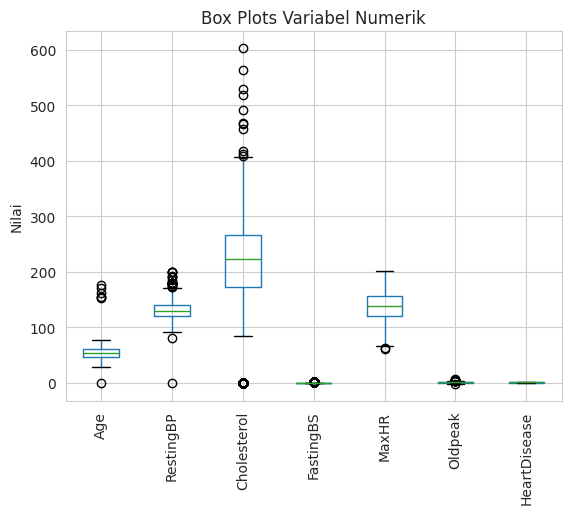

In [14]:
# Mengidentifikasi variabel numerik
numerical_cols = dataset.select_dtypes(include=np.number).columns

# Membuat box plot untuk setiap variabel numerik dalam satu frame dengan label vertikal
dataset[numerical_cols].boxplot(rot=90)
plt.title('Box Plots Variabel Numerik')
plt.ylabel('Nilai')
plt.show()

## 5. Pembersihan Data

Dari tahapan validasi data diketahui bahwa data harus dilakukan pembersihan pada

* Nilai kosong pada Age
* Nilai kosong pada Sex
* Jumlah outlier yang banyak pada Age, RestingBP, Cholesterol, dan MaxHR

### 1. Ganti variabel Age yang kosong dengan nilai modus

In [15]:
# Mengganti nilai kosong pada kolom 'Age' dengan nilai mediannya
dataset['Age'].fillna(dataset['Age'].median(), inplace=True)

# Memverifikasi bahwa nilai kosong pada kolom 'Age' telah terisi
print("Jumlah nilai kosong pada kolom 'Age' setelah imputasi:", dataset['Age'].isnull().sum())

Jumlah nilai kosong pada kolom 'Age' setelah imputasi: 0


/tmp/ipykernel_446/3187352041.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




2. Menghapus variabel Sex yang kosong

In [16]:
dataset.dropna(subset=['Sex'], inplace=True)

# Memverifikasi bahwa nilai kosong pada kolom 'Sex' telah terhapus
print("Jumlah nilai kosong pada kolom 'Sex' setelah penghapusan:", dataset['Sex'].isnull().sum())

Jumlah nilai kosong pada kolom 'Sex' setelah penghapusan: 0


### 3. Tangani outlier dengan IQR

In [17]:
# Menangani nilai outlier menggunakan metode IQR, kecuali untuk FastingBS, Oldpeak, dan HeartDisease
numerical_cols_to_handle = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

for col in numerical_cols_to_handle:
    if col in dataset.columns:
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Mengganti outlier
        dataset[col] = np.where(dataset[col] > upper_bound, Q3, dataset[col])
        dataset[col] = np.where(dataset[col] < lower_bound, Q1, dataset[col])
    else:
        print(f"Warning: Column '{col}' not found in dataset.")

print("Penanganan outlier untuk variabel terpilih selesai.")

Penanganan outlier untuk variabel terpilih selesai.


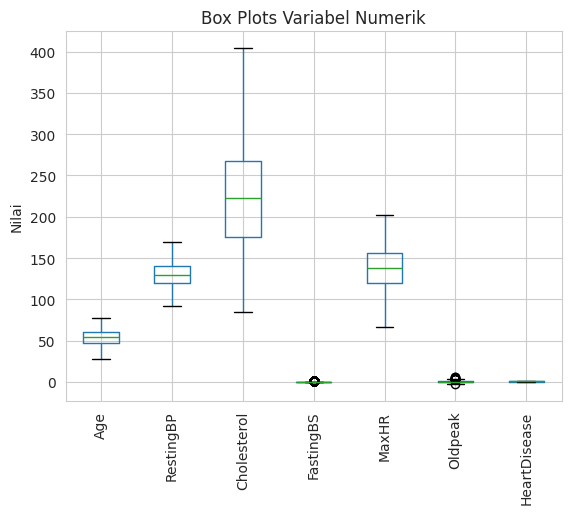

In [18]:
# Mengidentifikasi variabel numerik
numerical_cols = dataset.select_dtypes(include=np.number).columns

# Membuat box plot untuk setiap variabel numerik dalam satu frame dengan label vertikal
dataset[numerical_cols].boxplot(rot=90)
plt.title('Box Plots Variabel Numerik')
plt.ylabel('Nilai')
plt.show()

## 6. Penentuan Objek Data

### 1. Mengkonversi variabel kategorikal menjadi numerik menggunakan Ordinal Encoder

In [19]:
from sklearn.preprocessing import OrdinalEncoder

# Mengidentifikasi variabel kategorikal
categorical_cols = dataset.select_dtypes(include='object').columns

# Menginisialisasi OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Mengkonversi variabel kategorikal menjadi numerik
dataset[categorical_cols] = ordinal_encoder.fit_transform(dataset[categorical_cols])

print("Variabel kategorikal telah dikonversi menjadi numerik menggunakan OrdinalEncoder.")

Variabel kategorikal telah dikonversi menjadi numerik menggunakan OrdinalEncoder.


In [20]:
print(dataset.dtypes)

Age               float64
Sex               float64
ChestPainType     float64
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG        float64
MaxHR             float64
ExerciseAngina    float64
Oldpeak           float64
ST_Slope          float64
HeartDisease        int64
dtype: object


### 2.  Menampilkan matriks korelasi antar variabel menggunakan Heatmap

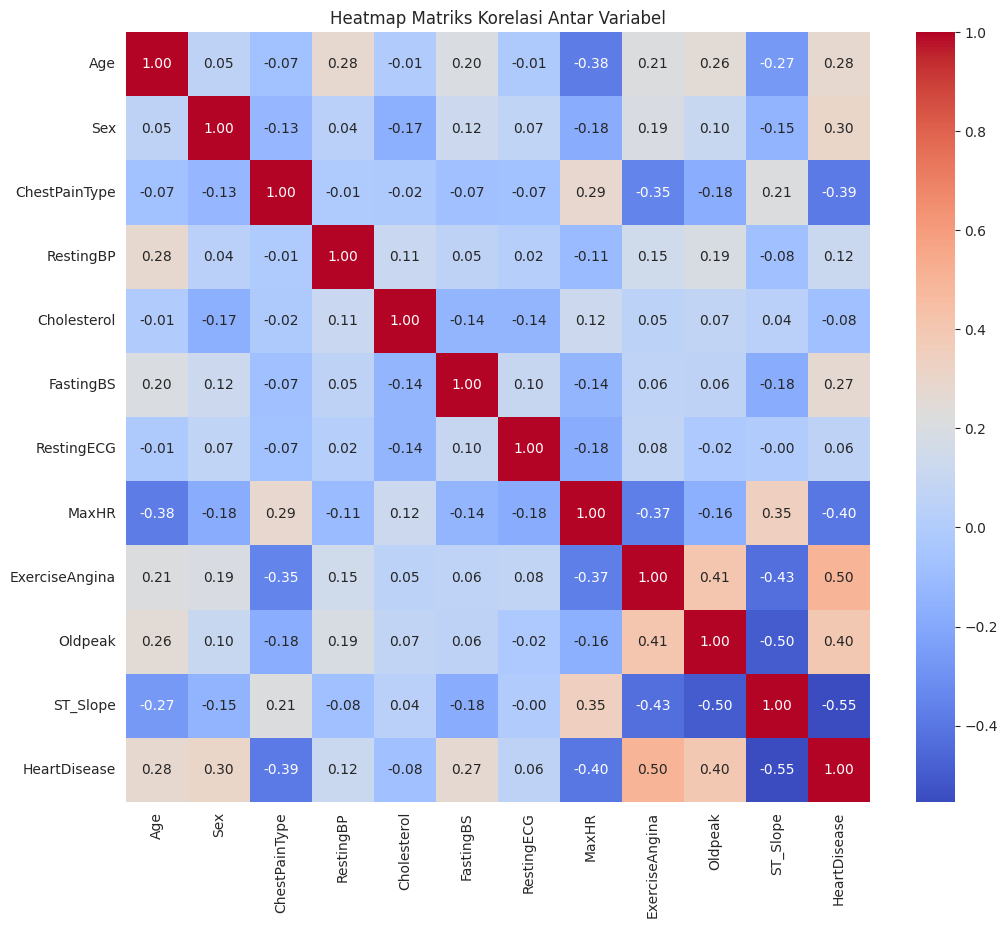

In [21]:
import seaborn as sns

# Hitung matriks korelasi
correlation_matrix = dataset.corr()

# Buat heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Matriks Korelasi Antar Variabel')
plt.show()

In [22]:
# Hitung matriks korelasi
correlation_matrix = dataset.corr()

# Urutkan variabel berdasarkan nilai absolut koefisien korelasi terhadap HeartDisease
correlation_with_heartdisease = correlation_matrix['HeartDisease'].abs().sort_values(ascending=False)

# Tampilkan hasil
print("Urutan variabel berdasarkan nilai absolut koefisien korelasi terhadap HeartDisease:")
print(correlation_with_heartdisease)

Urutan variabel berdasarkan nilai absolut koefisien korelasi terhadap HeartDisease:
HeartDisease      1.000000
ST_Slope          0.554575
ExerciseAngina    0.497976
Oldpeak           0.398315
MaxHR             0.397938
ChestPainType     0.387024
Sex               0.303381
Age               0.279649
FastingBS         0.273380
RestingBP         0.115686
Cholesterol       0.076478
RestingECG        0.056944
Name: HeartDisease, dtype: float64


### 3. Menghitung Skor Feature Importance setiap variabel

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Pisahkan fitur (X) dan variabel target (y)
X = dataset.drop('HeartDisease', axis=1)
y = dataset['HeartDisease']

# Inisialisasi dan latih model Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Dapatkan skor Feature Importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Tampilkan skor Feature Importance
print("Skor Feature Importance terhadap HeartDisease:")
print(feature_importances)

Skor Feature Importance terhadap HeartDisease:
ST_Slope          0.229753
ChestPainType     0.125540
Oldpeak           0.117017
MaxHR             0.109800
Cholesterol       0.097811
ExerciseAngina    0.083916
Age               0.078792
RestingBP         0.067778
Sex               0.036481
FastingBS         0.026673
RestingECG        0.026438
dtype: float64


### 4. Menghitung Skor SHAP setiap variabel

In [24]:
!pip -q install shap

In [25]:
import xgboost as xgb

# Inisialisasi dan latih model XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X, y)

print("Model XGBoost telah dilatih.")

Model XGBoost telah dilatih.


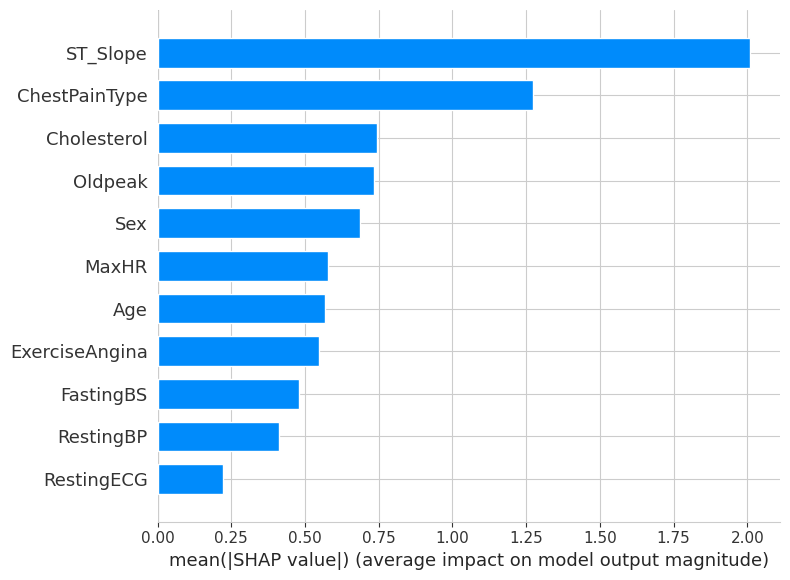

In [26]:
import shap

# Inisialisasi SHAP explainer untuk model XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)

# Hitung nilai SHAP untuk data menggunakan model XGBoost
shap_values_xgb = explainer_xgb.shap_values(X)

# Ringkasan plot SHAP untuk model XGBoost
shap.summary_plot(shap_values_xgb, X, plot_type="bar")

# Penceritaan Data dari Hasil Skor SHAP (Model XGBoost)

Hasil analisis SHAP pada model XGBoost memberikan wawasan mendalam tentang bagaimana setiap fitur memengaruhi prediksi model terkait kemungkinan penyakit jantung. Berdasarkan plot ringkasan SHAP:

1.  **ST_Slope (Kemiringan Segmen ST):** Fitur ini muncul sebagai prediktor paling penting. Titik-titik pada plot menunjukkan bahwa nilai `ST_Slope` yang tinggi (cenderung "Up" atau 2.0 setelah *encoding*) secara signifikan menurunkan nilai SHAP, yang berarti menurunkan kemungkinan prediksi penyakit jantung. Sebaliknya, nilai `ST_Slope` yang rendah (cenderung "Flat" atau 1.0 setelah *encoding*) memiliki nilai SHAP yang tinggi, yang berarti meningkatkan kemungkinan prediksi penyakit jantung. Ini konsisten dengan pemahaman medis bahwa ST *depression* (segmen ST mendatar atau turun) saat berolahraga seringkali merupakan indikator iskemia miokard.

2.  **ChestPainType (Jenis Nyeri Dada):** Fitur ini juga sangat penting. Plot SHAP menunjukkan bahwa jenis nyeri dada tertentu (kemungkinan "ASY" atau 0.0 setelah *encoding*) memiliki nilai SHAP yang tinggi, meningkatkan kemungkinan prediksi penyakit jantung. Sementara itu, jenis nyeri dada lainnya (seperti "ATA" atau 1.0 setelah *encoding*) memiliki nilai SHAP yang lebih rendah atau negatif, menurunkan kemungkinan prediksi penyakit jantung. Ini menyoroti pentingnya membedakan jenis nyeri dada dalam mendiagnosis penyakit jantung.

3.  **Oldpeak:** Fitur ini adalah prediktor penting ketiga. Nilai `Oldpeak` yang tinggi (menunjukkan depresi ST yang lebih besar) memiliki nilai SHAP yang tinggi, secara signifikan meningkatkan kemungkinan prediksi penyakit jantung. Sebaliknya, nilai `Oldpeak` yang rendah memiliki nilai SHAP yang rendah atau negatif, menurunkan kemungkinan prediksi penyakit jantung. Ini sejalan dengan peran `Oldpeak` sebagai indikator tingkat keparahan iskemia saat berolahraga.

Fitur-fitur lain seperti `MaxHR` (Detak Jantung Maksimum), `Cholesterol`, dan `ExerciseAngina` juga memiliki pengaruh yang cukup besar, meskipun sedikit di bawah tiga fitur teratas. Misalnya, `MaxHR` yang tinggi cenderung menurunkan kemungkinan prediksi penyakit jantung, sementara `ExerciseAngina` yang ada (nilai 1.0 setelah *encoding*) cenderung meningkatkan kemungkinan prediksi penyakit jantung.

Secara keseluruhan, analisis SHAP mengkonfirmasi bahwa fitur-fitur klinis kunci seperti `ST_Slope`, `ChestPainType`, dan `Oldpeak` adalah prediktor yang sangat kuat untuk penyakit jantung dalam dataset ini menurut model XGBoost. Memahami bagaimana nilai-nilai spesifik dari fitur-fitur ini memengaruhi prediksi model memberikan transparansi dan kepercayaan pada hasil model.

## 7. Konstruksi Data

### 1. Normalisasi Fitur (Min-Max Scaling)

Normalisasi (Min-Max Scaling) mengubah nilai-nilai fitur agar berada dalam rentang tertentu, biasanya antara 0 dan 1. Ini berguna untuk algoritma yang sensitif terhadap skala fitur, seperti algoritma berbasis jarak atau jaringan saraf.

In [27]:
from sklearn.preprocessing import MinMaxScaler

# Pisahkan fitur (X) dan variabel target (y)
X = dataset.drop('HeartDisease', axis=1)
y = dataset['HeartDisease']

# Identifikasi kolom numerik yang akan dinormalisasi (semua kecuali target HeartDisease sudah numerik setelah encoding)
numerical_cols_for_scaling = X.select_dtypes(include=np.number).columns

# Inisialisasi MinMaxScaler
min_max_scaler = MinMaxScaler()

# Terapkan Min-Max Scaling pada kolom numerik
X_normalized = X.copy()
X_normalized[numerical_cols_for_scaling] = min_max_scaler.fit_transform(X[numerical_cols_for_scaling])

# Gabungkan kembali dengan variabel target
dataset_normalized = pd.concat([X_normalized, y], axis=1)

print("Dataset setelah Min-Max Scaling:")
display(dataset_normalized.head())

Dataset setelah Min-Max Scaling:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.530612,1.0,0.333333,0.615385,0.639498,0.0,0.5,0.777778,0.0,0.295455,1.0,0
1,0.428571,0.0,0.666667,0.871795,0.297806,0.0,0.5,0.659259,0.0,0.409091,0.5,1
2,0.183673,1.0,0.333333,0.487179,0.620690,0.0,1.0,0.229630,0.0,0.295455,1.0,0
3,0.408163,0.0,0.000000,0.589744,0.404389,0.0,0.5,0.303704,1.0,0.465909,0.5,1
4,0.530612,1.0,0.666667,0.743590,0.344828,0.0,0.5,0.407407,0.0,0.295455,1.0,0


### 2. Standarisasi Fitur (Z-score Scaling)

Standarisasi (Z-score Scaling) mengubah data sehingga memiliki rata-rata nol dan standar deviasi satu. Ini sering digunakan untuk algoritma yang mengasumsikan distribusi normal atau yang berkinerja lebih baik ketika fitur-fitur berada pada skala yang sama.

In [28]:
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur (X) dan variabel target (y) dari dataset asli yang sudah di-encode
X = dataset.drop('HeartDisease', axis=1)
y = dataset['HeartDisease']

# Identifikasi kolom numerik yang akan distandarisasi (semua kecuali target HeartDisease sudah numerik setelah encoding)
numerical_cols_for_scaling = X.select_dtypes(include=np.number).columns

# Inisialisasi StandardScaler
standard_scaler = StandardScaler()

# Terapkan Standarisasi pada kolom numerik
X_standardized = X.copy()
X_standardized[numerical_cols_for_scaling] = standard_scaler.fit_transform(X[numerical_cols_for_scaling])

# Gabungkan kembali dengan variabel target
dataset_standardized = pd.concat([X_standardized, y], axis=1)

print("Dataset setelah Standarisasi (Z-score Scaling):")
display(dataset_standardized.head())

Dataset setelah Standarisasi (Z-score Scaling):


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.053923,0.516128,0.230112,0.552849,1.146832,-0.550205,0.022712,1.389450,-0.821752,-0.830999,1.053967,0
1,-0.478277,-1.937505,1.274820,1.828223,-0.937421,-0.550205,0.022712,0.755410,-0.821752,0.106094,-0.596037,1
2,-1.755556,0.516128,0.230112,-0.084838,1.032102,-0.550205,1.609071,-1.542985,-0.821752,-0.830999,1.053967,0
3,-0.584717,-1.937505,-0.814596,0.425312,-0.287287,-0.550205,0.022712,-1.146710,1.216912,0.574640,-0.596037,1
4,0.053923,0.516128,1.274820,1.190536,-0.650597,-0.550205,0.022712,-0.591925,-0.821752,-0.830999,1.053967,0


### 3. Binning Variabel 'Age'

Binning adalah proses mengelompokkan nilai-nilai kontinu ke dalam kategori diskrit (bin). Ini dapat membantu dalam menangani *outlier*, mengurangi kebisingan, dan membuat data lebih mudah diinterpretasikan untuk beberapa model.

In [29]:
# Buat salinan dataset untuk binning
dataset_binned = dataset.copy()

# Tentukan batas bin dan label untuk kolom 'Age'
bins = [0, 40, 50, 60, 70, np.inf] # Misalnya: <40, 40-49, 50-59, 60-69, 70+
labels = ['<40', '40-49', '50-59', '60-69', '70+']

# Terapkan binning pada kolom 'Age'
dataset_binned['Age_Binned'] = pd.cut(dataset_binned['Age'], bins=bins, labels=labels, right=False)

print("Distribusi 'Age' setelah Binning:")
display(dataset_binned[['Age', 'Age_Binned']].head())
print("\nJumlah data per kategori usia setelah Binning:")
display(dataset_binned['Age_Binned'].value_counts())

Distribusi 'Age' setelah Binning:


,Age,Age_Binned
0,54.0,50-59
1,49.0,40-49
2,37.0,<40
3,48.0,40-49
4,54.0,50-59



Jumlah data per kategori usia setelah Binning:


,count
Age_Binned,
50-59,368
60-69,223
40-49,209
<40,79
70+,29


### 4. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) adalah teknik pengurangan dimensi yang mengubah kumpulan variabel yang mungkin berkorelasi menjadi sekumpulan variabel yang tidak berkorelasi linier yang disebut komponen utama. Tujuannya adalah untuk mempertahankan variabilitas data sebanyak mungkin dengan jumlah fitur yang lebih sedikit.

In [30]:
from sklearn.decomposition import PCA

# Gunakan dataset yang sudah distandardisasi untuk PCA
# Pisahkan fitur (X) dan variabel target (y)
X_for_pca = dataset_standardized.drop('HeartDisease', axis=1)
y_for_pca = dataset_standardized['HeartDisease']

# Inisialisasi PCA. Kita akan mencoba 2 komponen utama terlebih dahulu.
pca = PCA(n_components=2)

# Terapkan PCA pada data
X_pca = pca.fit_transform(X_for_pca)

# Buat DataFrame untuk hasil PCA
pca_df = pd.DataFrame(data = X_pca, columns = ['Principal Component 1', 'Principal Component 2'])

# Gabungkan kembali dengan variabel target (opsional, untuk analisis lebih lanjut)
pca_df = pd.concat([pca_df, y_for_pca.reset_index(drop=True)], axis = 1)

print("Explained variance ratio per principal component:")
print(pca.explained_variance_ratio_)
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")

print("\nDataset setelah PCA (2 Komponen Utama):")
display(pca_df.head())

Explained variance ratio per principal component:
[0.24765683 0.12698733]
Total explained variance by 2 components: 0.37

Dataset setelah PCA (2 Komponen Utama):


,Principal Component 1,Principal Component 2,HeartDisease
0,-1.667088,0.699978,0
1,-1.008025,0.971157,1
2,-1.075735,-1.030624,0
3,1.092962,0.764902,1
4,-0.986220,-0.525204,0


## 8. Pemodelan Data

### 1. Membuat Salinan Data

In [31]:
OldDataset = dataset

### 2. Membagi dataset menjadi matriks data dan vektor target

In [32]:
# Memilih variabel fitur (X) dan variabel target (y) berdasarkan analisis sebelumnya
X = dataset[['ST_Slope', 'ChestPainType', 'Oldpeak', 'Cholesterol', 'Sex']]
y = dataset['HeartDisease']

print("Variabel fitur (X) dan variabel target (y) telah dibagi.")
print("Bentuk matriks X:", X.shape)
print("Bentuk vektor y:", y.shape)

Variabel fitur (X) dan variabel target (y) telah dibagi.
Bentuk matriks X: (908, 5)
Bentuk vektor y: (908,)


### 3. Hold-out Cross Validation

In [33]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi data training (80%) dan data testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data telah dibagi menjadi set pelatihan dan pengujian.")
print("Bentuk X_train:", X_train.shape)
print("Bentuk X_test:", X_test.shape)
print("Bentuk y_train:", y_train.shape)
print("Bentuk y_test:", y_test.shape)

Data telah dibagi menjadi set pelatihan dan pengujian.
Bentuk X_train: (726, 5)
Bentuk X_test: (182, 5)
Bentuk y_train: (726,)
Bentuk y_test: (182,)


# **Pemodelan Decision Tree**

**1.  Training Model Decision Tree (max depth = 3)**

Metrik Kinerja Model Decision Tree (max_depth=3):
Accuracy: 0.8407
Precision: 0.8317
Recall: 0.8750
F1 Score: 0.8528
AUC-ROC: 0.8985

Classification Report (max_depth=3):
              precision    recall  f1-score   support

           0       0.85      0.80      0.83        86
           1       0.83      0.88      0.85        96

    accuracy                           0.84       182
   macro avg       0.84      0.84      0.84       182
weighted avg       0.84      0.84      0.84       182



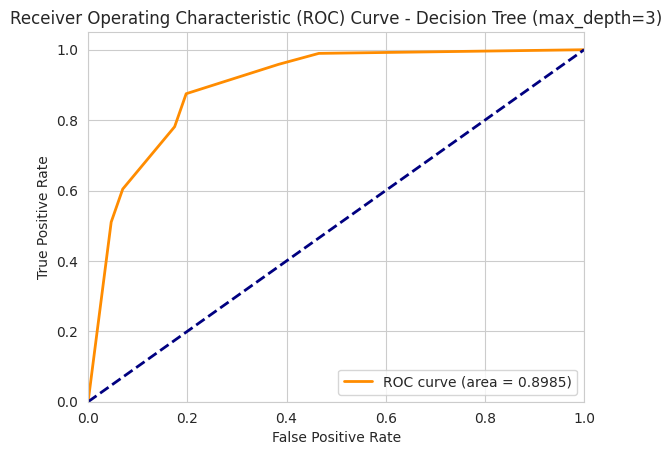

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Decision Tree dengan max_depth = 3
model_dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)

# Latih model menggunakan data training
model_dt_pruned.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt_pruned = model_dt_pruned.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_dt_pruned = accuracy_score(y_test, y_pred_dt_pruned)
precision_dt_pruned = precision_score(y_test, y_pred_dt_pruned)
recall_dt_pruned = recall_score(y_test, y_pred_dt_pruned)
f1_dt_pruned = f1_score(y_test, y_pred_dt_pruned)
fpr_dt_pruned, tpr_dt_pruned, thresholds_dt_pruned = roc_curve(y_test, model_dt_pruned.predict_proba(X_test)[:, 1])
auc_dt_pruned = auc(fpr_dt_pruned, tpr_dt_pruned)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Decision Tree (max_depth=3):")
print(f"Accuracy: {accuracy_dt_pruned:.4f}")
print(f"Precision: {precision_dt_pruned:.4f}")
print(f"Recall: {recall_dt_pruned:.4f}")
print(f"F1 Score: {f1_dt_pruned:.4f}")
print(f"AUC-ROC: {auc_dt_pruned:.4f}")

# Tampilkan classification report
print("\nClassification Report (max_depth=3):")
print(classification_report(y_test, y_pred_dt_pruned))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_dt_pruned, tpr_dt_pruned, color='darkorange', lw=2, label=f'ROC curve (area = {auc_dt_pruned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree (max_depth=3)')
plt.legend(loc="lower right")
plt.show()

**Menampilkan model decision tree hasil training**

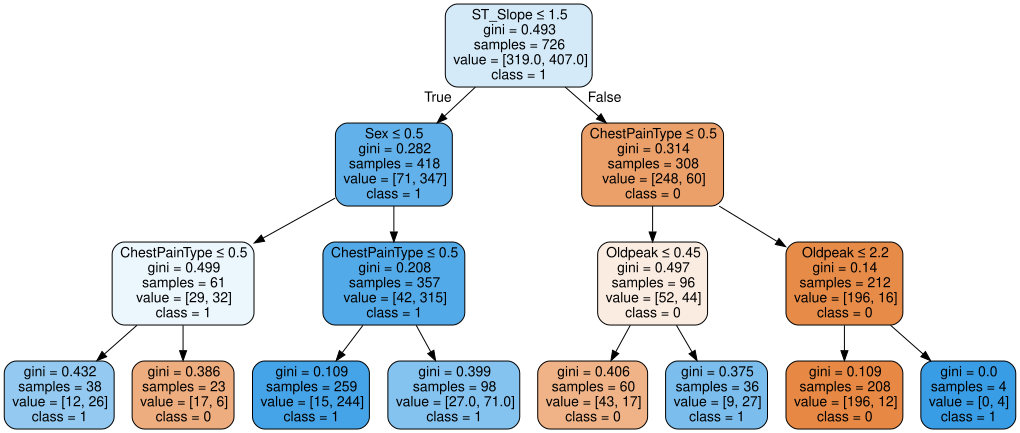

In [35]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(model_dt_pruned,
     out_file=None,
     feature_names=X.columns,
     class_names=['0','1'],
     filled=True, rounded=True,
     special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)

**2. Training Model Decision Tree (max depth = 4)**

Metrik Kinerja Model Decision Tree (max_depth=3):
Accuracy: 0.8242
Precision: 0.8019
Recall: 0.8854
F1 Score: 0.8416
AUC-ROC: 0.8741

Classification Report (max_depth=3):
              precision    recall  f1-score   support

           0       0.86      0.76      0.80        86
           1       0.80      0.89      0.84        96

    accuracy                           0.82       182
   macro avg       0.83      0.82      0.82       182
weighted avg       0.83      0.82      0.82       182



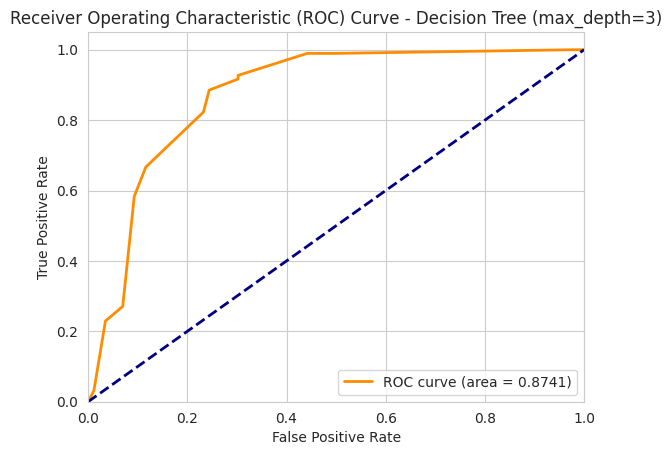

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Decision Tree dengan max_depth = 4
model_dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)

# Latih model menggunakan data training
model_dt_pruned.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt_pruned = model_dt_pruned.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_dt_pruned = accuracy_score(y_test, y_pred_dt_pruned)
precision_dt_pruned = precision_score(y_test, y_pred_dt_pruned)
recall_dt_pruned = recall_score(y_test, y_pred_dt_pruned)
f1_dt_pruned = f1_score(y_test, y_pred_dt_pruned)
fpr_dt_pruned, tpr_dt_pruned, thresholds_dt_pruned = roc_curve(y_test, model_dt_pruned.predict_proba(X_test)[:, 1])
auc_dt_pruned = auc(fpr_dt_pruned, tpr_dt_pruned)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Decision Tree (max_depth=3):")
print(f"Accuracy: {accuracy_dt_pruned:.4f}")
print(f"Precision: {precision_dt_pruned:.4f}")
print(f"Recall: {recall_dt_pruned:.4f}")
print(f"F1 Score: {f1_dt_pruned:.4f}")
print(f"AUC-ROC: {auc_dt_pruned:.4f}")

# Tampilkan classification report
print("\nClassification Report (max_depth=4):")
print(classification_report(y_test, y_pred_dt_pruned))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_dt_pruned, tpr_dt_pruned, color='darkorange', lw=2, label=f'ROC curve (area = {auc_dt_pruned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree (max_depth=4)')
plt.legend(loc="lower right")
plt.show()

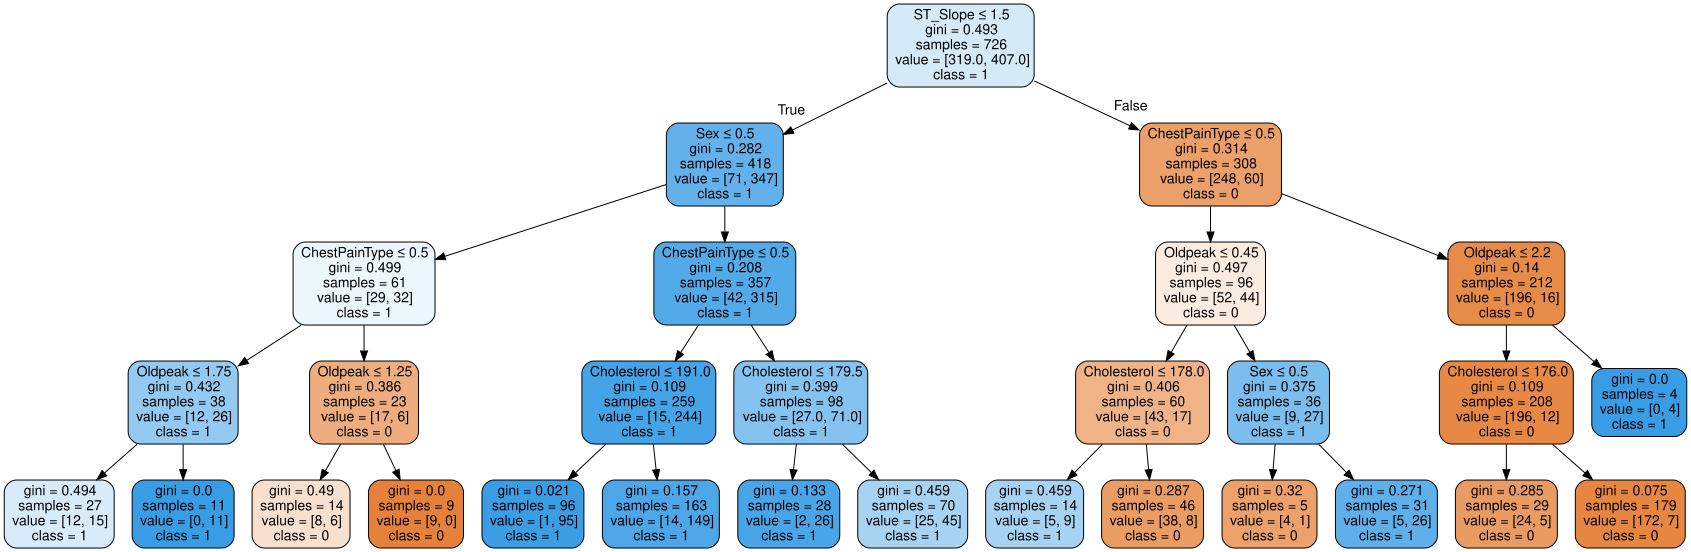

In [37]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(model_dt_pruned,
     out_file=None,
     feature_names=X.columns,
     class_names=['0','1'],
     filled=True, rounded=True,
     special_characters=True)
graph = graphviz.Source(dot_data)
display(graph)

**3. Training Model Decision Tree (max depth = 5)**

Metrik Kinerja Model Decision Tree (max_depth=3):
Accuracy: 0.8242
Precision: 0.7963
Recall: 0.8958
F1 Score: 0.8431
AUC-ROC: 0.8640

Classification Report (max_depth=3):
              precision    recall  f1-score   support

           0       0.86      0.74      0.80        86
           1       0.80      0.90      0.84        96

    accuracy                           0.82       182
   macro avg       0.83      0.82      0.82       182
weighted avg       0.83      0.82      0.82       182



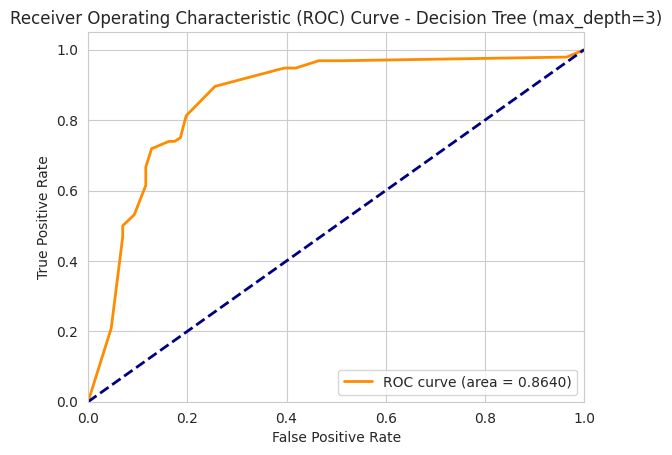

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Decision Tree dengan max_depth = 5
model_dt_pruned = DecisionTreeClassifier(max_depth=5, random_state=42)

# Latih model menggunakan data training
model_dt_pruned.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt_pruned = model_dt_pruned.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_dt_pruned = accuracy_score(y_test, y_pred_dt_pruned)
precision_dt_pruned = precision_score(y_test, y_pred_dt_pruned)
recall_dt_pruned = recall_score(y_test, y_pred_dt_pruned)
f1_dt_pruned = f1_score(y_test, y_pred_dt_pruned)
fpr_dt_pruned, tpr_dt_pruned, thresholds_dt_pruned = roc_curve(y_test, model_dt_pruned.predict_proba(X_test)[:, 1])
auc_dt_pruned = auc(fpr_dt_pruned, tpr_dt_pruned)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Decision Tree (max_depth=3):")
print(f"Accuracy: {accuracy_dt_pruned:.4f}")
print(f"Precision: {precision_dt_pruned:.4f}")
print(f"Recall: {recall_dt_pruned:.4f}")
print(f"F1 Score: {f1_dt_pruned:.4f}")
print(f"AUC-ROC: {auc_dt_pruned:.4f}")

# Tampilkan classification report
print("\nClassification Report (max_depth=3):")
print(classification_report(y_test, y_pred_dt_pruned))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_dt_pruned, tpr_dt_pruned, color='darkorange', lw=2, label=f'ROC curve (area = {auc_dt_pruned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree (max_depth=3)')
plt.legend(loc="lower right")
plt.show()

# **Pemodelan Random Forest**

**1. Training Model Random Forest (n_estimator = 20)**

Metrik Kinerja Model Random Forest (n_estimators=20):
Accuracy: 0.8022
Precision: 0.8000
Recall: 0.8333
F1 Score: 0.8163
AUC-ROC: 0.8633

Classification Report (n_estimators=20):
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        86
           1       0.80      0.83      0.82        96

    accuracy                           0.80       182
   macro avg       0.80      0.80      0.80       182
weighted avg       0.80      0.80      0.80       182



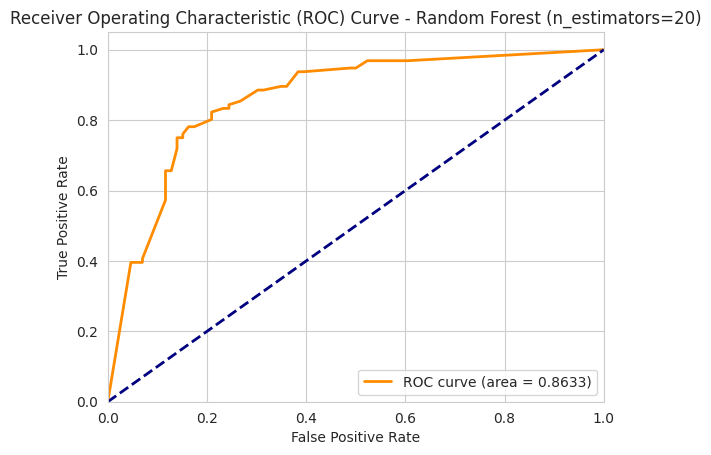

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Random Forest dengan 20 pohon
model_rf = RandomForestClassifier(n_estimators=20, random_state=42)

# Latih model menggunakan data training
model_rf.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_rf = model_rf.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1])
auc_rf = auc(fpr_rf, tpr_rf)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Random Forest (n_estimators=20):")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")

# Tampilkan classification report
print("\nClassification Report (n_estimators=20):")
print(classification_report(y_test, y_pred_rf))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest (n_estimators=20)')
plt.legend(loc="lower right")
plt.show()

**2. Training Model Random Forest (n_estimator = 50)**

Metrik Kinerja Model Random Forest (n_estimators=20):
Accuracy: 0.8077
Precision: 0.8081
Recall: 0.8333
F1 Score: 0.8205
AUC-ROC: 0.8649

Classification Report (n_estimators=20):
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        86
           1       0.81      0.83      0.82        96

    accuracy                           0.81       182
   macro avg       0.81      0.81      0.81       182
weighted avg       0.81      0.81      0.81       182



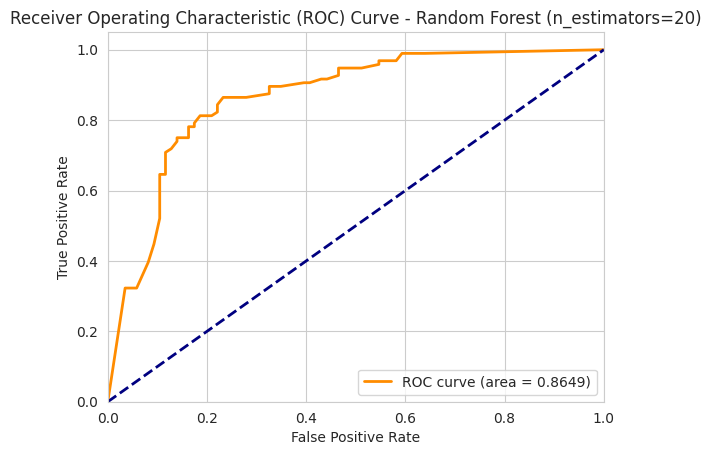

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Random Forest dengan 50 pohon
model_rf = RandomForestClassifier(n_estimators=50, random_state=42)

# Latih model menggunakan data training
model_rf.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_rf = model_rf.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1])
auc_rf = auc(fpr_rf, tpr_rf)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Random Forest (n_estimators=20):")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_rf:.4f}")

# Tampilkan classification report
print("\nClassification Report (n_estimators=20):")
print(classification_report(y_test, y_pred_rf))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest (n_estimators=20)')
plt.legend(loc="lower right")
plt.show()

# **Pemodelan Logistic Regression**

Metrik Kinerja Model Logistic Regression:
Accuracy: 0.8077
Precision: 0.8081
Recall: 0.8333
F1 Score: 0.8205
AUC-ROC: 0.8550

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        86
           1       0.81      0.83      0.82        96

    accuracy                           0.81       182
   macro avg       0.81      0.81      0.81       182
weighted avg       0.81      0.81      0.81       182



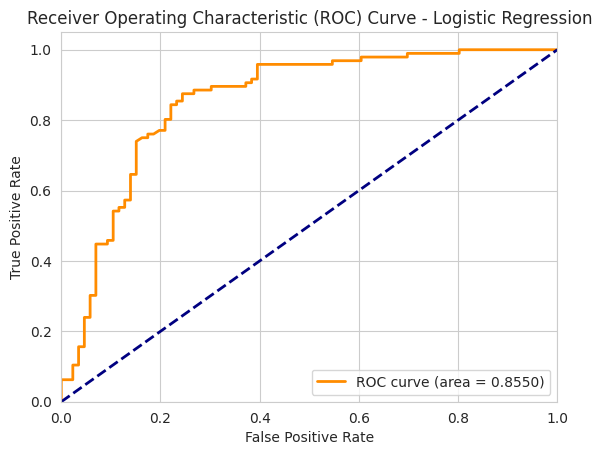

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Inisialisasi model Logistic Regression
model_lr = LogisticRegression(random_state=42)

# Latih model menggunakan data training
model_lr.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_lr = model_lr.predict(X_test)

# Hitung metrik kinerja klasifikasi
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, model_lr.predict_proba(X_test)[:, 1])
auc_lr = auc(fpr_lr, tpr_lr)

# Tampilkan metrik kinerja
print("Metrik Kinerja Model Logistic Regression:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")

# Tampilkan classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Gambarkan kurva ROC
plt.figure()
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# **Pemodelan Klasifikasi Menggunakan AUTOML**

In [42]:
!pip -q install mljar-supervised

In [43]:
from supervised.automl import AutoML
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

# Ignore specific warnings from matplotlib font manager
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")


# 1. Load dataset
# 2. Inisialisasi AutoML
automl = AutoML(
    mode="Explain",              # mode bisa "Explain", "Perform", "Compete", "Optuna"
    total_time_limit=300,        # waktu total training dalam detik
    eval_metric="accuracy",      # metrik evaluasi
    #algorithms=["LightGBM", "Xgboost", "CatBoost", "RandomForest"],  # algoritma yang digunakan
    algorithms=['Baseline', 'CatBoost', 'Decision Tree', 'Extra Trees', 'Nearest Neighbors', 'LightGBM', 'Linear', "Neural Network", 'Random Forest', 'Xgboost'],
    random_state=42
)

# 3. Latih model
automl.fit(X_train, y_train)

# 4. Prediksi dan evaluasi
y_pred = automl.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))

# 5. Tampilkan leaderboard model
print("Leaderboard model:", automl.get_leaderboard())

AutoML directory: AutoML_1
The task is binary_classification with evaluation metric accuracy
AutoML will use algorithms: ['Baseline', 'CatBoost', 'Decision Tree', 'Extra Trees', 'Nearest Neighbors', 'LightGBM', 'Linear', 'Neural Network', 'Random Forest', 'Xgboost']
AutoML is generating and selecting models automatically. Review outputs before important use.
AutoML will ensemble available models
AutoML steps: ['simple_algorithms', 'default_algorithms', 'ensemble']
* Step simple_algorithms will try to check up to 3 models
1_Baseline accuracy 0.56044 trained in 0.55 seconds


2_DecisionTree accuracy 0.857143 trained in 31.38 seconds


3_Linear accuracy 0.824176 trained in 13.94 seconds
* Step default_algorithms will try to check up to 7 models
4_Default_LightGBM accuracy 0.895604 trained in 3.41 seconds
5_Default_Xgboost accuracy 0.879121 trained in 3.61 seconds
6_Default_CatBoost accuracy 0.895604 trained in 2.1 seconds
7_Default_NeuralNetwork accuracy 0.873626 trained in 2.19 seconds
8_Default_RandomForest accuracy 0.884615 trained in 2.89 seconds
9_Default_ExtraTrees accuracy 0.879121 trained in 2.73 seconds
'KNeighborsAlgorithm' object has no attribute 'classes_'
Problem during computing permutation importance. Skipping ...
10_Default_NearestNeighbors accuracy 0.873626 trained in 2.09 seconds
* Step ensemble will try to check up to 1 model
Ensemble accuracy 0.912088 trained in 2.12 seconds
AutoML fit time: 87.53 seconds
AutoML best model: Ensemble
Akurasi: 0.8241758241758241
Leaderboard model:                            name         model_type metric_type  metric_value  \
0                    1_Baseline         

In [44]:
import joblib
import os
import pandas as pd

# Dapatkan leaderboard untuk mengidentifikasi model terbaik
leaderboard = automl.get_leaderboard()

# Dapatkan nama model terbaik dari leaderboard (model dengan metric_value terendah)
best_model_name = leaderboard.iloc[0]['name']

# Filter leaderboard untuk mendapatkan model dasar terbaik (bukan Baseline atau Ensemble)
base_models_leaderboard = leaderboard[~leaderboard['model_type'].isin(['Baseline', 'Ensemble'])]

if not base_models_leaderboard.empty:
    # Dapatkan nama model dasar terbaik
    best_base_model_name = base_models_leaderboard.iloc[0]['name']
    print(f"Model dasar terbaik (selain Ensemble) adalah: {best_base_model_name}")

    # Coba simpan objek AutoML itu sendiri
    try:
        filename_automl_object = 'automl_object.joblib'
        joblib.dump(automl, filename_automl_object)
        print(f"Objek AutoML telah disimpan ke dalam file '{filename_automl_object}'.")
        print("Anda dapat memuat objek ini nanti untuk mengakses model atau hasil.")
    except Exception as e:
        print(f"Gagal menyimpan objek AutoML: {e}")
        print("Mencoba menyimpan model dasar terbaik dari direktori output...")

        model_dir_path = os.path.join('AutoML_2', best_base_model_name)
        # Mencari file model di dalam direktori model
        model_files = [f for f in os.listdir(model_dir_path) if os.path.isfile(os.path.join(model_dir_path, f))]

        if model_files:
            # Ambil file pertama yang ditemukan (ini mungkin perlu disesuaikan)
            model_file_to_save = model_files[0]
            model_file_path = os.path.join(model_dir_path, model_file_to_save)

            try:
                # Muat model dari file
                loaded_model = joblib.load(model_file_path)
                # Tentukan nama file untuk menyimpan ulang
                filename_base_model = f'{best_base_model_name}_model.joblib'
                # Simpan model dasar terbaik ke dalam file
                joblib.dump(loaded_model, filename_base_model)
                print(f"Model dasar terbaik '{best_base_model_name}' telah disimpan ke dalam file '{filename_base_model}'.")
            except Exception as e:
                 print(f"Gagal memuat atau menyimpan model dasar terbaik dari '{model_file_path}': {e}")
                 print("Mungkin format file model tidak didukung oleh joblib atau ada masalah jalur.")

        else:
            print(f"Tidak ada file model yang ditemukan di direktori '{model_dir_path}'.")
            print("Struktur direktori output MLJAR mungkin berbeda dari yang diharapkan.")

else:
    print("Tidak ada model dasar (selain Baseline atau Ensemble) yang ditemukan di leaderboard.")

Model dasar terbaik (selain Ensemble) adalah: 2_DecisionTree
Objek AutoML telah disimpan ke dalam file 'automl_object.joblib'.
Anda dapat memuat objek ini nanti untuk mengakses model atau hasil.


Objek AutoML berhasil dimuat dari 'automl_object.joblib'.

Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat):
Accuracy: 0.8242
Precision: 0.8137
Recall: 0.8646
F1 Score: 0.8384
AUC-ROC: 0.8698

Classification Report Model Terbaik (dari objek AutoML yang dimuat):
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        86
           1       0.81      0.86      0.84        96

    accuracy                           0.82       182
   macro avg       0.83      0.82      0.82       182
weighted avg       0.82      0.82      0.82       182



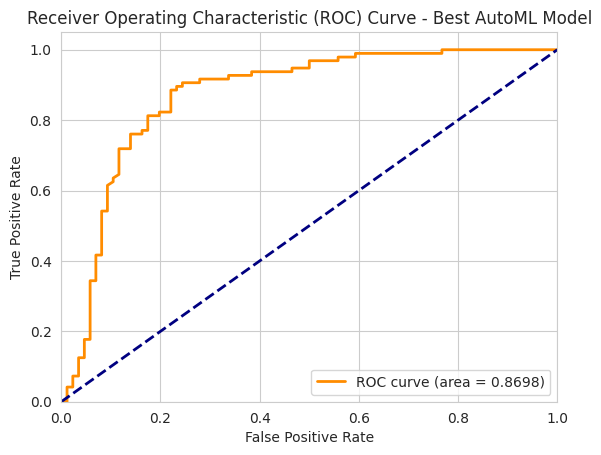

In [49]:
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt


# Nama file tempat objek AutoML disimpan
filename_automl_object = 'automl_object.joblib'

# Muat objek AutoML dari file
try:
    loaded_automl = joblib.load(filename_automl_object)
    print(f"Objek AutoML berhasil dimuat dari '{filename_automl_object}'.")

    # Lakukan prediksi pada data testing menggunakan objek AutoML yang dimuat
    y_pred_loaded_automl = loaded_automl.predict(X_test)
    y_proba_loaded_automl = loaded_automl.predict_proba(X_test)[:, 1]


    # Hitung metrik kinerja klasifikasi
    accuracy_loaded_automl = accuracy_score(y_test, y_pred_loaded_automl)
    precision_loaded_automl = precision_score(y_test, y_pred_loaded_automl)
    recall_loaded_automl = recall_score(y_test, y_pred_loaded_automl)
    f1_loaded_automl = f1_score(y_test, y_pred_loaded_automl)
    fpr_loaded_automl, tpr_loaded_automl, thresholds_loaded_automl = roc_curve(y_test, y_proba_loaded_automl)
    auc_loaded_automl = auc(fpr_loaded_automl, tpr_loaded_automl)

    # Tampilkan metrik kinerja
    print("\nMetrik Kinerja Model Terbaik (dari objek AutoML yang dimuat):")
    print(f"Accuracy: {accuracy_loaded_automl:.4f}")
    print(f"Precision: {precision_loaded_automl:.4f}")
    print(f"Recall: {recall_loaded_automl:.4f}")
    print(f"F1 Score: {f1_loaded_automl:.4f}")
    print(f"AUC-ROC: {auc_loaded_automl:.4f}")

    # Tampilkan classification report
    print("\nClassification Report Model Terbaik (dari objek AutoML yang dimuat):")
    print(classification_report(y_test, y_pred_loaded_automl))

    # Gambarkan kurva ROC
    plt.figure()
    plt.plot(fpr_loaded_automl, tpr_loaded_automl, color='darkorange', lw=2, label=f'ROC curve (area = {auc_loaded_automl:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Best AutoML Model')
    plt.legend(loc="lower right")
    plt.show()


except FileNotFoundError:
    print(f"Error: File '{filename_automl_object}' tidak ditemukan.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat atau menggunakan objek AutoML: {e}")

In [50]:
# Evaluate the loaded AutoML model on the training data
y_pred_train_automl = loaded_automl.predict(X_train)
y_proba_train_automl = loaded_automl.predict_proba(X_train)[:, 1]

# Calculate training metrics
accuracy_train_automl = accuracy_score(y_train, y_pred_train_automl)
precision_train_automl = precision_score(y_train, y_pred_train_automl)
recall_train_automl = recall_score(y_train, y_pred_train_automl)
f1_train_automl = f1_score(y_train, y_pred_train_automl)
fpr_train_automl, tpr_train_automl, thresholds_train_automl = roc_curve(y_train, y_proba_train_automl)
auc_train_automl = auc(fpr_train_automl, tpr_train_automl)

print("Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TRAINING:")
print(f"Accuracy: {accuracy_train_automl:.4f}")
print(f"Precision: {precision_train_automl:.4f}")
print(f"Recall: {recall_train_automl:.4f}")
print(f"F1 Score: {f1_train_automl:.4f}")
print(f"AUC-ROC: {auc_train_automl:.4f}")

print("\nMetrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TESTING:")
print(f"Accuracy: {accuracy_loaded_automl:.4f}")
print(f"Precision: {precision_loaded_automl:.4f}")
print(f"Recall: {recall_loaded_automl:.4f}")
print(f"F1 Score: {f1_loaded_automl:.4f}")
print(f"AUC-ROC: {auc_loaded_automl:.4f}")

print("\nPerbandingan Kinerja (Training vs Testing):")
print(f"Accuracy Delta (Training - Testing): {accuracy_train_automl - accuracy_loaded_automl:.4f}")
print(f"Precision Delta (Training - Testing): {precision_train_automl - precision_loaded_automl:.4f}")
print(f"Recall Delta (Training - Testing): {recall_train_automl - recall_loaded_automl:.4f}")
print(f"F1 Score Delta (Training - Testing): {f1_train_automl - f1_loaded_automl:.4f}")
print(f"AUC-ROC Delta (Training - Testing): {auc_train_automl - auc_loaded_automl:.4f}")

Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TRAINING:
Accuracy: 0.9036
Precision: 0.8910
Recall: 0.9435
F1 Score: 0.9165
AUC-ROC: 0.9592

Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TESTING:
Accuracy: 0.8242
Precision: 0.8137
Recall: 0.8646
F1 Score: 0.8384
AUC-ROC: 0.8698

Perbandingan Kinerja (Training vs Testing):
Accuracy Delta (Training - Testing): 0.0794
Precision Delta (Training - Testing): 0.0772
Recall Delta (Training - Testing): 0.0789
F1 Score Delta (Training - Testing): 0.0781
AUC-ROC Delta (Training - Testing): 0.0895


Berdasarkan metrik kinerja model terbaik (dari objek AutoML yang dimuat) pada DATA TRAINING dan DATA TESTING:

Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TRAINING:
*   Accuracy: 0.9036
*   Precision: 0.8910
*   Recall: 0.9435
*   F1 Score: 0.9165
*   AUC-ROC: 0.9592

Metrik Kinerja Model Terbaik (dari objek AutoML yang dimuat) pada DATA TESTING:
*   Accuracy: 0.8242
*   Precision: 0.8137
*   Recall: 0.8646
*   F1 Score: 0.8384
*   AUC-ROC: 0.8698

Perbandingan Kinerja (Training vs Testing):
*   Accuracy Delta (Training - Testing): 0.0794
*   Precision Delta (Training - Testing): 0.0772
*   Recall Delta (Training - Testing): 0.0789
*   F1 Score Delta (Training - Testing): 0.0781
*   AUC-ROC Delta (Training - Testing): 0.0895

**Kesimpulan Overfitting:**

Nilai delta yang positif dan cukup besar pada semua metrik (sekitar 0.08 hingga 0.09) antara kinerja pada data training dan data testing menunjukkan bahwa model AutoML terbaik **cenderung mengalami *overfitting***.

Ini berarti model belajar pola pada data training dengan sangat baik (mencapai kinerja tinggi), tetapi kinerjanya menurun ketika dihadapkan pada data testing yang belum pernah dilihat sebelumnya. Penurunan kinerja ini adalah indikasi bahwa model mungkin terlalu kompleks atau terlalu spesifik mempelajari detail dari data training, sehingga tidak dapat digeneralisasikan dengan baik pada data baru.

Meskipun akurasi pada data testing masih cukup baik (sekitar 0.82), perbedaan yang signifikan dengan akurasi training (sekitar 0.90) menunjukkan adanya *overfitting* yang perlu diperhatikan.